# Demand Forecasting with External Economic Signals

Forecasting monthly demand for a dealer-distributed durable good, where customer
economics drive purchases with a lead time of several months.

**Data is synthetic** (`src/generate.py`), seeded and reproducible — no proprietary data.
The true lead times are hidden from the modelling code, so lag recovery is a real problem.

This notebook is organised around three ways a forecasting backtest lies, each measured:
leakage, lag selection, and sign instability.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import generate as G, features as F, leakage as L, models as M

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.25})
INK, ACCENT, MUTED = "#2b3a55", "#c2643f", "#8896ab"
MIN_TRAIN = 84

## 1. The series

168 months, 2012-01 to 2025-12
oracle R2 ceiling: 0.884


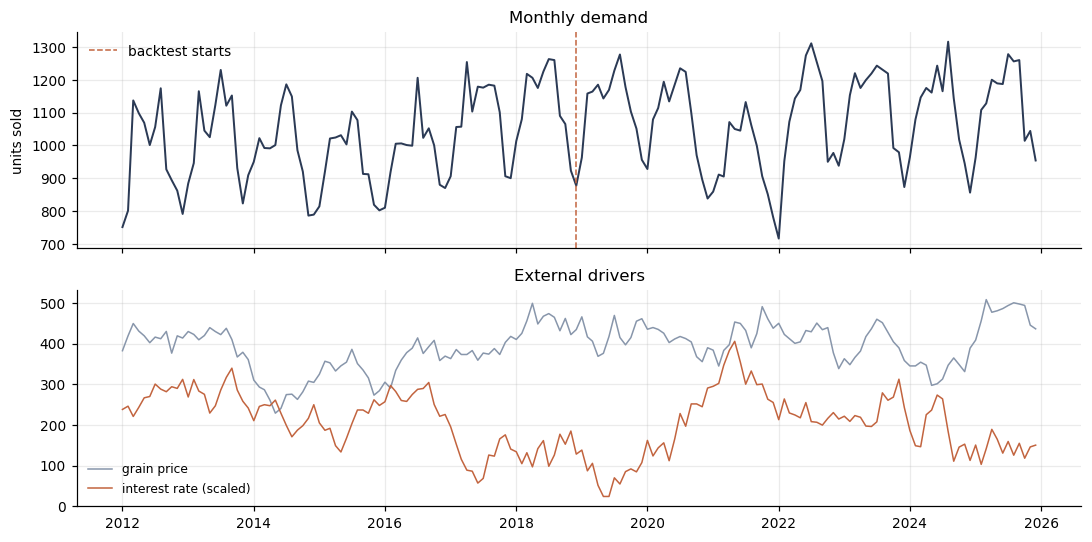

In [2]:
raw = G.make_dataset()
train_end = raw.index[MIN_TRAIN - 1]
ceiling = 1 - np.var(raw[G.TARGET] - raw["_signal_no_noise"]) / np.var(raw[G.TARGET])
print(f"{len(raw)} months, {raw.index[0]:%Y-%m} to {raw.index[-1]:%Y-%m}")
print(f"oracle R2 ceiling: {ceiling:.3f}")

fig, ax = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
ax[0].plot(raw.index, raw[G.TARGET], color=INK, lw=1.3)
ax[0].axvline(train_end, color=ACCENT, ls="--", lw=1, label="backtest starts")
ax[0].set_ylabel("units sold"); ax[0].legend(frameon=False); ax[0].set_title("Monthly demand")
ax[1].plot(raw.index, raw["grain_price"], color=MUTED, lw=1, label="grain price")
ax[1].plot(raw.index, raw["interest_rate"] * 60, color=ACCENT, lw=1, label="interest rate (scaled)")
ax[1].legend(frameon=False, fontsize=8); ax[1].set_title("External drivers")
plt.tight_layout(); plt.show()

## 2. Leak 1 — feature timing

Internal aggregates like `unique_dealers` and `stock_on_lot` describe the *same month* as
the sales they measure. They correlate strongly with demand because they are partly caused
by it. Using them unlagged puts the answer in the features.

The audit compares each feature's correlation with `y(t)` against `y(t+1)`. A real leading
indicator predicts the future; a leaked one describes the present.

In [3]:
map_leaky = {r.feature: int(r.selected_lag)
             for r in L.select_lags(raw, G.EXTERNAL_COLS, train_end=None).itertuples()}
mat_leaky = F.build_matrix(G.drop_oracle(raw), map_leaky,
                           include_contemporaneous_internal=True, drop_raw_external=False)
XA, yA = F.xy(mat_leaky)
L.audit_feature_timing(XA, yA, top_n=8).round(3)

,feature,corr_with_y_t,corr_with_y_t+1,contemporaneous_excess,suspect
0,units_sold_lag2,0.474,0.133,0.341,True
1,units_sold_roll3_mean,0.519,0.189,0.330,True
2,units_sold_lag1,0.765,0.474,0.290,True
3,stock_on_lot,-0.547,-0.297,0.250,True
4,month_cos2,-0.239,0.025,0.214,False
5,precipitation,0.516,0.338,0.178,True
6,units_sold_lag12,0.752,0.614,0.137,True
7,unique_dealers,0.652,0.536,0.116,True


Now run the same models under both pipelines and price the difference.

In [4]:
resA = M.rolling_origin_backtest(XA, yA, min_train=MIN_TRAIN)

delayed = G.apply_publication_delay(raw)
wm = F.add_segment_margins(delayed)
map_honest = L.lag_map(L.select_lags(wm, G.DRIVER_COLS, train_end=train_end), minimum=1)
mat_honest = F.build_matrix(G.drop_oracle(wm), map_honest,
                            include_contemporaneous_internal=False, drop_raw_external=True)
XB, yB = F.xy(mat_honest)
resB = M.rolling_origin_backtest(XB, yB, min_train=MIN_TRAIN)

pd.DataFrame([
    {"model": m,
     "leaky_mae": resA.metrics.set_index("model").loc[m, "mae"],
     "honest_mae": resB.metrics.set_index("model").loc[m, "mae"],
     "overstated_pct": 100 * (resB.metrics.set_index("model").loc[m, "mae"]
                              - resA.metrics.set_index("model").loc[m, "mae"])
                       / resB.metrics.set_index("model").loc[m, "mae"]}
    for m in ["ridge", "gbm", "seasonal_naive"]]).round(2)

,model,leaky_mae,honest_mae,overstated_pct
0,ridge,44.18,49.94,11.54
1,gbm,50.02,57.84,13.52
2,seasonal_naive,59.71,60.49,1.29


The baseline is unaffected — it has no features to leak. **When only the feature-driven models improve, that is the signature of a leak**, not of learning.

## 3. Leak 2 — selection, and why lag scanning fails

Scanning lags 0–12 for the highest correlation is standard practice. Here it is beaten by
guessing 3. The drivers are persistent (AR(1), φ ≈ 0.9–0.97), so the correlation profile is
nearly flat in the lag and the argmax is noise-dominated.

In [5]:
specs = {
    "oracle (true lead times)":     {k: max(v, 1) for k, v in G.TRUE_LAGS.items()},
    "flat lag = 3 (no selection)":  {k: 3 for k in G.DRIVER_COLS},
    "scan on full series (leak)":   L.lag_map(L.select_lags(wm, G.DRIVER_COLS, train_end=None), 1),
    "scan on train window only":    L.lag_map(L.select_lags(wm, G.DRIVER_COLS, train_end=train_end), 1),
    "flat lag = 1 (no selection)":  {k: 1 for k in G.DRIVER_COLS},
}
rows = []
for label, lm in specs.items():
    mat = F.build_matrix(G.drop_oracle(wm), lm,
                         include_contemporaneous_internal=False, drop_raw_external=True)
    Xs, ys = F.xy(mat)
    mm = M.rolling_origin_backtest(Xs, ys, min_train=MIN_TRAIN).metrics.set_index("model")
    rows.append({"lag specification": label, "ridge_mase": mm.loc["ridge", "mase"],
                 "gbm_mase": mm.loc["gbm", "mase"]})
pd.DataFrame(rows).round(3)

,lag specification,ridge_mase,gbm_mase
0,oracle (true lead times),0.749,0.898
1,flat lag = 3 (no selection),0.783,0.900
2,scan on full series (leak),0.801,0.945
3,scan on train window only,0.826,0.956
4,flat lag = 1 (no selection),0.820,0.934


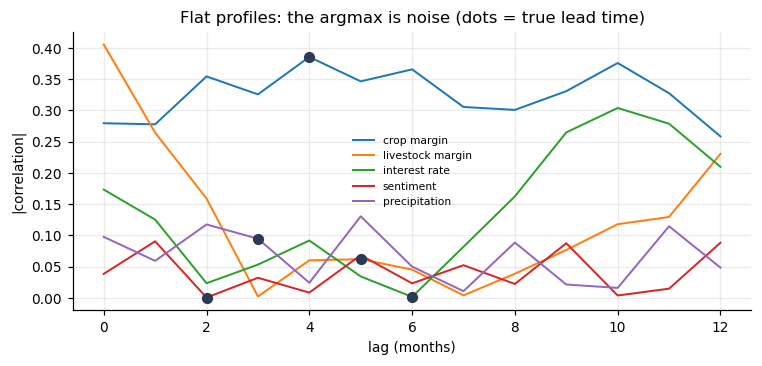

In [6]:
scan = wm.loc[:train_end]
yd = scan[G.TARGET].shift(-1); yd = yd - yd.shift(12)
plt.figure(figsize=(7, 3.4))
for col in G.DRIVER_COLS:
    cs = []
    for k in range(13):
        f = scan[col].shift(k); f = f - f.shift(12)
        cs.append(abs(f.corr(yd)))
    plt.plot(range(13), cs, lw=1.3, label=col.replace("_", " "))
    if col in G.TRUE_LAGS:
        plt.scatter([G.TRUE_LAGS[col]], [cs[G.TRUE_LAGS[col]]], s=40, zorder=5, color=INK)
plt.xlabel("lag (months)"); plt.ylabel("|correlation|")
plt.title("Flat profiles: the argmax is noise (dots = true lead time)")
plt.legend(frameon=False, fontsize=7); plt.tight_layout(); plt.show()

Lags matter — the oracle row is much better. But that information is not recoverable from correlations, so **lag choice belongs to domain knowledge of the customer's decision cycle**, not to a scan.

## 4. The sign-flip problem

Grain price is revenue for a crop grower and a feed cost for a livestock operation. One
coefficient cannot represent both, and collinearity with feed cost makes the fitted sign
unstable. The fix is to build segment margins — revenue leg minus cost leg — so each
feature is signed correctly by construction.

In [7]:
from sklearn.linear_model import LinearRegression
sgn = wm.copy(); sgn["y_ds"] = sgn[G.TARGET] - sgn[G.TARGET].shift(12)

def sign_study(cols, label, lag=4, win=60, step=3):
    sub = sgn[["y_ds"]].copy()
    for c in cols:
        sub[c] = sgn[c].shift(lag) - sgn[c].shift(lag + 12)
    sub = sub.dropna()
    Xs = sub[cols].to_numpy(float); Xs = (Xs - Xs.mean(0)) / Xs.std(0)
    yy = sub["y_ds"].to_numpy()
    C = np.array([LinearRegression().fit(Xs[s:s+win], yy[s:s+win]).coef_
                  for s in range(0, len(sub) - win, step)])
    return pd.DataFrame([{"specification": label, "feature": c,
                          "sign_consistency": max((np.sign(C[:, i]) > 0).mean(),
                                                  (np.sign(C[:, i]) < 0).mean()),
                          "mean_coef": C[:, i].mean()} for i, c in enumerate(cols)])

pd.concat([sign_study(["grain_price", "livestock_price", "feed_cost"], "raw prices"),
           sign_study(["crop_margin", "livestock_margin"], "segment margins")],
          ignore_index=True).round(2)

,specification,feature,sign_consistency,mean_coef
0,raw prices,grain_price,0.55,7.98
1,raw prices,livestock_price,0.61,14.81
2,raw prices,feed_cost,0.52,4.71
3,segment margins,crop_margin,0.87,30.35
4,segment margins,livestock_margin,0.65,4.98


## 5. Honest skill and decision metrics

Point accuracy is not the decision. A planner asks *"should we build inventory?"* — a
classification question against a causally-computed rolling threshold.

In [8]:
display(resB.metrics.round(3))
pd.DataFrame([M.threshold_events(resB.predictions, m)
              for m in ["ridge", "gbm", "seasonal_naive"]]).round(3)

,model,rmse,mae,mape_pct,mase,direction_acc
0,ridge,63.674,49.941,4.834,0.826,0.800
1,gbm,69.304,57.840,5.546,0.956,0.743
2,seasonal_naive,76.288,60.493,5.662,1.000,0.786
3,drift_naive,95.350,75.041,7.201,1.240,0.471


,model,n,precision,recall,f1,tp,fp,fn,tn
0,ridge,59,0.643,0.600,0.621,9,5,6,39
1,gbm,59,0.727,0.533,0.615,8,3,7,41
2,seasonal_naive,59,0.556,0.667,0.606,10,8,5,36


80% coverage (ridge): 0.729 on 59 origins


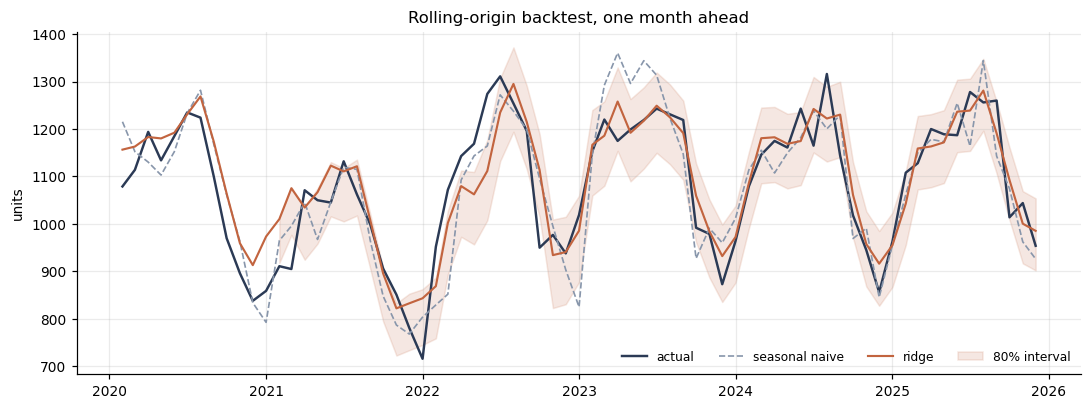

In [9]:
best = resB.metrics.iloc[0]["model"]
iv = M.residual_intervals(resB.predictions, best, level=0.8)
print(f"80% coverage ({best}): {iv['covered'].mean():.3f} "
      f"on {int(iv['covered'].notna().sum())} origins")

p = resB.predictions
plt.figure(figsize=(10, 3.8))
plt.plot(p.index, p["actual"], color=INK, lw=1.6, label="actual")
plt.plot(p.index, p["seasonal_naive"], color=MUTED, lw=1.1, ls="--", label="seasonal naive")
plt.plot(p.index, p[best], color=ACCENT, lw=1.4, label=f"{best}")
ok = iv["lo"].notna()
plt.fill_between(iv.index[ok], iv["lo"][ok], iv["hi"][ok], color=ACCENT, alpha=0.15,
                 label="80% interval")
plt.ylabel("units"); plt.legend(frameon=False, ncol=4, fontsize=8)
plt.title("Rolling-origin backtest, one month ahead"); plt.tight_layout(); plt.show()

## 6. What I would do next

- **Extend to a 3–12 month horizon.** One-step-ahead is the easy case; planning decisions
  need longer, where error compounds and lag structure matters more.
- **Go hierarchical.** Real forecasting runs over hundreds of SKU–region cells, where
  reconciliation and cross-series pooling beat per-series models.
- **Get the lead times from the business, not the data.** Section 3 is the strongest
  argument in this repo: interviewing planners about the customer decision cycle would
  likely beat any scan.
- **Monitor for regime change.** The generator has no structural break; real series do,
  and that is the main reason backtests overstate live performance.